<a href="https://colab.research.google.com/github/Jmian1520/Accidental_Drug_Related_Deaths_Case_Analysis/blob/main/Accidental_Drug_Related_Deaths.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read file
df = pd.read_csv('Accidental_Drug_Related_Deaths.csv')

In [ ]:
#Showing the head of dataset
print("Dataset First 5 row")
df.head()

Dataset First 5 row


,Date,Date Type,Age,Sex,Race,Ethnicity,Residence City,Residence County,Residence State,Injury City,...,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Other Opioid,Any Opioid,Other,ResidenceCityGeo,InjuryCityGeo,DeathCityGeo,Year
0,05/29/2012,Date of death,37.0,male,black,unknown,stamford,fairfield,unknown,stamford,...,N,N,N,Unknown,N,Unknown,"STAMFORD, CT\n(41.051924, -73.539475)","STAMFORD, CT\n(41.051924, -73.539475)","CT\n(41.575155, -72.738288)",2012
1,06/27/2012,Date of death,37.0,male,white,unknown,norwich,new london,unknown,norwich,...,N,N,N,Unknown,N,Unknown,"NORWICH, CT\n(41.524304, -72.075821)","NORWICH, CT\n(41.524304, -72.075821)","Norwich, CT\n(41.524304, -72.075821)",2012
2,03/24/2014,Date of death,28.0,male,white,unknown,hebron,unknown,unknown,other city,...,N,N,N,Unknown,N,Unknown,"HEBRON, CT\n(41.658069, -72.366324)","HEBRON, CT\n(41.658069, -72.366324)","Marlborough, CT\n(41.632043, -72.461309)",2014
3,12/31/2014,Date of death,26.0,female,white,unknown,baltic,unknown,unknown,unknown,...,N,N,N,Unknown,N,Unknown,"BALTIC, CT\n(41.617221, -72.085031)","CT\n(41.575155, -72.738288)","Baltic, CT\n(41.617221, -72.085031)",2014
4,01/16/2016,Date of death,41.0,male,white,unknown,shelton,fairfield,ct,other city,...,N,N,N,Unknown,Y,Unknown,"SHELTON, CT\n(41.316843, -73.092968)","SHELTON, CT\n(41.316843, -73.092968)","Bridgeport, CT\n(41.179195, -73.189476)",2016


In [ ]:
#Showing dataset information
print("\nDataset Information such as dataypes, column names")
print(df.info())


Dataset Information such as dataypes, column names
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11981 entries, 0 to 11980
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date                           11981 non-null  object 
 1   Date Type                      11981 non-null  object 
 2   Age                            11981 non-null  float64
 3   Sex                            11981 non-null  object 
 4   Race                           11981 non-null  object 
 5   Ethnicity                      11981 non-null  object 
 6   Residence City                 11981 non-null  object 
 7   Residence County               11981 non-null  object 
 8   Residence State                11981 non-null  object 
 9   Injury City                    11981 non-null  object 
 10  Injury County                  11981 non-null  object 
 11  Injury State                   11981 non-null  object 

Preprocessing

In [ ]:
#Missing Values
print("Missing values:")
df.isnull().sum()

Missing values:


,0
Date,0
Date Type,0
Age,0
Sex,0
Race,0
Ethnicity,0
Residence City,0
Residence County,0
Residence State,0
Injury City,0


In [ ]:
# Checking Duplicated Records
print("Duplicated records:")
df.duplicated().sum()

Duplicated records:


np.int64(0)

In [ ]:
# Handling Missing Value
# 1. Drug-related Columns
substance_cols = ['Heroin','Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
       'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine',
       'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)',
       'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Any Opioid']  # list all 23

# Fill NaN with 'N'
for col in substance_cols:
    df[col] = df[col].fillna('N')

# 2. Handle other categorical features
cate_cols = ['Sex', 'Race', 'Ethnicity',
       'Residence City', 'Residence County', 'Residence State', 'Injury City',
       'Injury County', 'Injury State', 'Injury Place',
       'Description of Injury', 'Death City', 'Death County', 'Death State',
       'Location', 'Location if Other', 'Cause of Death', 'Manner of Death',
       'Other Significant Conditions ', 'Other', 'ResidenceCityGeo',
       'InjuryCityGeo', 'DeathCityGeo','Other Opioid','Other']

# Fill NaN with 'Unknown'
for col in cate_cols:
    df[col] = df[col].fillna('Unknown')


# 3. Age: Fill in with median
df['Age'] = df['Age'].fillna(df['Age'].median())

#4. Print Missing Values again
print("Missing values:")
df.isnull().sum()

Missing values:


,0
Date,0
Date Type,0
Age,0
Sex,0
Race,0
Ethnicity,0
Residence City,0
Residence County,0
Residence State,0
Injury City,0


Data Mapping

In [ ]:
# Convert all data to lowercase
df['Race'] = df['Race'].str.lower()
# mapping
race_mapping = {
    'black or african american': 'black',
    'black or african american / american indian lenni lenape': 'black',
    'asian indian': 'asian',
    'asian, other': 'asian',
    'other asian': 'asian',
    'chinese': 'asian',
    'korean': 'asian',
    'asian/indian': 'asian',
    'american indian or alaska native': 'native american',
    'native american, other': 'native american',
    'other (specify) haitian': 'other',
    'other (specify) portugese, cape verdean': 'other',
    'other (specify) puerto rican': 'other',
    'white': 'white',
    'black': 'black',
    'asian': 'asian',
    'unknown': 'unknown',
    'other': 'other',
    'other (specify)': 'other',
    'hawaiian': 'other',
    'other asian (specify)': 'asian'
}

#Replace and show again
df['Race'] = df['Race'].replace(race_mapping)
print("Race column standardized using the defined mapping.")
print("\nUnique values and their counts for standardized 'Race' column:")
print(df['Race'].value_counts())

Race column standardized using the defined mapping.

Unique values and their counts for standardized 'Race' column:
Race
white              10082
black               1636
unknown              119
asian                 73
other                 69
native american        2
Name: count, dtype: int64


In [ ]:
df['Sex'] = df['Sex'].str.lower()

sex_mapping = {
    'male': 'male',
    'female': 'female',
    'unknown': 'unknown',
    'x': 'unknown' # Mapping 'x' to 'unknown'
}

df['Sex'] = df['Sex'].replace(sex_mapping)
print("Sex column standardized using the refined mapping.")
print("\nUnique values and their counts for standardized 'Sex' column:")
print(df['Sex'].value_counts())

df['Ethnicity'] = df['Ethnicity'].str.lower()
ethnicity_mapping = {
    'hispanic/latino': 'hispanic',
    'hispanic': 'hispanic',
    'not hispanic': 'non-hispanic',
    'non-hispanic': 'non-hispanic',
    'unknown': 'unknown',
    'no, not spanish/hispanic/latino': 'non-hispanic',
    'spanish/hispanic/latino': 'hispanic',
    'other spanish/hispanic/latino': 'hispanic',
    'yes, other spanish/hispanic/latino': 'hispanic',
    'not spanish/hispanic/latino': 'non-hispanic',
    'yes, other spanish/hispanic/latino (specify)': 'hispanic',
    'puerto rican': 'hispanic',
    'yes, puerto rican': 'hispanic',
    'yes, mexican, mexican american, chicano': 'hispanic',
    'mexican, mexican american, chicano': 'hispanic',
    'cuban': 'hispanic'
}

df['Ethnicity'] = df['Ethnicity'].replace(ethnicity_mapping)
print("\nEthnicity column standardized using the refined mapping.")
print("\nUnique values and their counts for standardized 'Ethnicity' column:")
print(df['Ethnicity'].value_counts())

Sex column standardized using the refined mapping.

Unique values and their counts for standardized 'Sex' column:
Sex
male       8887
female     3082
unknown      12
Name: count, dtype: int64

Ethnicity column standardized using the refined mapping.

Unique values and their counts for standardized 'Ethnicity' column:
Ethnicity
unknown         9433
hispanic        1760
non-hispanic     788
Name: count, dtype: int64


Clustering

In [ ]:
# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Features Selection
cluster_features = ['Age','Sex','Race','Ethnicity']
df_cluster = df[cluster_features]
df_cluster

,Age,Sex,Race,Ethnicity
0,37.0,male,black,unknown
1,37.0,male,white,unknown
2,28.0,male,white,unknown
3,26.0,female,white,unknown
4,41.0,male,white,unknown
...,...,...,...,...
11976,58.0,female,white,non-hispanic
11977,23.0,male,white,hispanic
11978,46.0,male,white,non-hispanic
11979,44.0,male,white,hispanic


In [ ]:
# One-hot encode categorical columns
df_cluster = pd.get_dummies(df_cluster, columns=['Sex', 'Race', 'Ethnicity'], drop_first=True)

# Display the updated dataframe for df_cluster
print('df_cluster after One-Hot Encoding:')
print(df_cluster.shape)
print(df_cluster.head())

df_cluster after One-Hot Encoding:
(11981, 10)
    Age  Sex_male  Sex_unknown  Race_black  Race_native american  Race_other  \
0  37.0      True        False        True                 False       False   
1  37.0      True        False       False                 False       False   
2  28.0      True        False       False                 False       False   
3  26.0     False        False       False                 False       False   
4  41.0      True        False       False                 False       False   

   Race_unknown  Race_white  Ethnicity_non-hispanic  Ethnicity_unknown  
0         False       False                   False               True  
1         False        True                   False               True  
2         False        True                   False               True  
3         False        True                   False               True  
4         False        True                   False               True  


In [ ]:
scaler = StandardScaler()

X_cluster = scaler.fit_transform(df_cluster)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2,7)

for k in k_values:
    sklearn_kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    sklearn_kmeans.fit(X_cluster)

    sklearn_labels = sklearn_kmeans.labels_
    sklearn_centroids = pd.DataFrame(sklearn_kmeans.cluster_centers_, columns=df_cluster.columns)

    print(f"--------------k={k}------------\n")
    print('Sklearn KMeans Labels count:')
    print(pd.Series(sklearn_labels).value_counts())
    print('\nSklearn KMeans Centroids:')
    print(sklearn_centroids,"\n")

--------------k=2------------

Sklearn KMeans Labels count:
1    10132
0     1849
Name: count, dtype: int64

Sklearn KMeans Centroids:
        Age  Sex_male  Sex_unknown  Race_black  Race_native american  \
0  0.263063 -0.000907     0.036616    2.174964              0.070669   
1 -0.048099  0.000166    -0.006695   -0.397673             -0.012921   

   Race_other  Race_unknown  Race_white  Ethnicity_non-hispanic  \
0    0.416253      0.547798   -2.304151                0.122404   
1   -0.076108     -0.100160    0.421294               -0.022380   

   Ethnicity_unknown  
0           0.131777  
1          -0.024094   

--------------k=3------------

Sklearn KMeans Labels count:
0    9512
2    1681
1     788
Name: count, dtype: int64

Sklearn KMeans Centroids:
        Age  Sex_male  Sex_unknown  Race_black  Race_native american  \
0 -0.070028  0.000096    -0.015046   -0.397673             -0.012921   
1  0.344674 -0.053656     0.128811    0.245398             -0.012921   
2  0.234682  0.0

Classification


In [ ]:
# classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [ ]:
# Feature Selection
df_class = df[['Age','Sex','Race','Ethnicity',
       'Heroin','Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
       'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine',
       'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)',
       'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Any Opioid']]
df_class

,Age,Sex,Race,Ethnicity,Heroin,Heroin death certificate (DC),Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,...,Meth/Amphetamine,Amphet,Tramad,Hydromorphone,Morphine (Not Heroin),Xylazine,Gabapentin,Opiate NOS,Heroin/Morph/Codeine,Any Opioid
0,37.0,male,black,unknown,N,N,Y,N,N,N,...,N,N,N,N,N,N,N,N,N,N
1,37.0,male,white,unknown,Y,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
2,28.0,male,white,unknown,Y,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
3,26.0,female,white,unknown,Y,N,N,N,N,N,...,N,N,N,N,N,N,N,N,N,N
4,41.0,male,white,unknown,N,N,N,Y,N,N,...,N,N,N,N,N,N,N,N,N,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11976,58.0,female,white,non-hispanic,N,N,Y,N,N,N,...,N,N,N,N,N,N,N,N,N,N
11977,23.0,male,white,hispanic,N,N,N,Y,N,N,...,N,N,N,N,N,N,N,N,N,Y
11978,46.0,male,white,non-hispanic,N,N,N,N,N,Y,...,N,N,N,N,N,N,N,N,N,Y
11979,44.0,male,white,hispanic,N,N,Y,Y,Y,N,...,N,N,N,N,N,Y,N,N,N,Y


In [ ]:
# Encoding and Scaling
#Select drug related column for label encoding
drug_columns = [
       'Heroin','Heroin death certificate (DC)', 'Cocaine', 'Fentanyl',
       'Fentanyl Analogue', 'Oxycodone', 'Oxymorphone', 'Ethanol',
       'Hydrocodone', 'Benzodiazepine', 'Methadone', 'Meth/Amphetamine',
       'Amphet', 'Tramad', 'Hydromorphone', 'Morphine (Not Heroin)',
       'Xylazine', 'Gabapentin', 'Opiate NOS', 'Heroin/Morph/Codeine', 'Any Opioid'
]

# Label encoding for drug-related columns within df_class
# manually set "Yes" > 1 and "No" > 0
substance_map = {'Y': 1, 'N': 0}
for col in drug_columns:
  df_class[col] = df_class[col].map(substance_map).fillna(0).astype(int)

# One-hot encoding for categorical varaibles
df_class = pd.get_dummies(df_class, columns=['Sex', 'Race', 'Ethnicity'], drop_first=True)

#Initialize Standard Scaler
scaler = StandardScaler()
# Select all numerical feautures and apply standard scaler
df_class['Age'] = scaler.fit_transform(df_class[['Age']])

# Display df_class to confirm transformations
print("df_class after all transformations:")
print(df_class.head())

df_class after all transformations:
        Age  Heroin  Heroin death certificate (DC)  Cocaine  Fentanyl  \
0 -0.553051       0                              0        1         0   
1 -0.553051       1                              0        0         0   
2 -1.262982       1                              0        0         0   
3 -1.420745       1                              0        0         0   
4 -0.237526       0                              0        0         1   

   Fentanyl Analogue  Oxycodone  Oxymorphone  Ethanol  Hydrocodone  ...  \
0                  0          0            0        0            0  ...   
1                  0          0            0        0            0  ...   
2                  0          0            0        0            0  ...   
3                  0          0            0        0            0  ...   
4                  0          0            0        0            0  ...   

   Any Opioid  Sex_male  Sex_unknown  Race_black  Race_native american  \


/tmp/ipykernel_1563/2827563583.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class[col] = df_class[col].map(substance_map).fillna(0).astype(int)
/tmp/ipykernel_1563/2827563583.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_class[col] = df_class[col].map(substance_map).fillna(0).astype(int)
/tmp/ipykernel_1563/2827563583.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [ ]:
# Data Spliting
X = df_class.drop(['Any Opioid'], axis=1)
y = df_class['Any Opioid'] # Target Varible

# Split to training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the results
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (9584, 30)
Testing set size: (2397, 30)


In [ ]:
# Implement Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
# Implement XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42,
                    scale_pos_weight=10,
                    learning_rate=0.05,
                    max_depth=5,
                    n_estimators=200)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

Anomaly Detection

In [ ]:
# Using the same data with classification
df_anomaly = df_class.copy()
df_anomaly

,Age,Heroin,Heroin death certificate (DC),Cocaine,Fentanyl,Fentanyl Analogue,Oxycodone,Oxymorphone,Ethanol,Hydrocodone,...,Any Opioid,Sex_male,Sex_unknown,Race_black,Race_native american,Race_other,Race_unknown,Race_white,Ethnicity_non-hispanic,Ethnicity_unknown
0,-0.553051,0,0,1,0,0,0,0,0,0,...,0,True,False,True,False,False,False,False,False,True
1,-0.553051,1,0,0,0,0,0,0,0,0,...,0,True,False,False,False,False,False,True,False,True
2,-1.262982,1,0,0,0,0,0,0,0,0,...,0,True,False,False,False,False,False,True,False,True
3,-1.420745,1,0,0,0,0,0,0,0,0,...,0,False,False,False,False,False,False,True,False,True
4,-0.237526,0,0,0,1,0,0,0,0,0,...,1,True,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11976,1.103455,0,0,1,0,0,0,0,0,0,...,0,False,False,False,False,False,False,True,True,False
11977,-1.657389,0,0,0,1,0,0,0,0,0,...,1,True,False,False,False,False,False,True,False,False
11978,0.156880,0,0,0,0,0,1,1,1,0,...,1,True,False,False,False,False,False,True,True,False
11979,-0.000882,0,0,1,1,1,0,0,0,0,...,1,True,False,False,False,False,False,True,False,False


In [ ]:
# Implement Isolation Forest
from sklearn.ensemble import IsolationForest
iso = IsolationForest(random_state=42,contamination=0.05)

iso_pred = iso.fit_predict(df_anomaly)

df_anomaly['IsolationForest_Anomaly'] = iso_pred

In [ ]:
# Implement LOF
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20,contamination=0.05)

lof_pred = lof.fit_predict(df_anomaly)

df_anomaly['LOF_Anomaly'] = lof_pred

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


Evaluation


In [ ]:
#Clustering
# Range of k values
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster)

    #Initialize silhouette and elbow
    score = silhouette_score(X_cluster, labels)
    elbow = kmeans.inertia_
    print(f"k={k}, silhouette score={score}, elbow score={elbow}")

k=2, silhouette score=0.3556833745085796, elbow score=104494.01752014658
k=3, silhouette score=0.33181816760668986, elbow score=94728.99078886461
k=4, silhouette score=0.4368316131548376, elbow score=76167.16381134585
k=5, silhouette score=0.4382731162799318, elbow score=64182.979190594444
k=6, silhouette score=0.441005522457176, elbow score=52188.6075643755


In [ ]:
#Classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# initialize the report
def evaluate_model(y_test, y_pred, y_pred_proba, model_name):
    print(f"\n{model_name} Evaluation metrics:")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", round(precision_score(y_test, y_pred), 4))
    print("Recall:", round(recall_score(y_test, y_pred), 4))
    print("F1 Score:", round(f1_score(y_test, y_pred), 4))
    print("ROC-AUC (Probability):", round(roc_auc_score(y_test, y_pred_proba), 4))

# Get probability predictions for ROC-AUC
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Get binary predictions
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Evaluate all models with enhanced function
evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBoost Classifier")


Random Forest Evaluation metrics:
Accuracy: 0.8794
Precision: 0.9107
Recall: 0.9228
F1 Score: 0.9167
ROC-AUC (Probability): 0.9244

XGBoost Classifier Evaluation metrics:
Accuracy: 0.8477
Precision: 0.829
Recall: 0.993
F1 Score: 0.9036
ROC-AUC (Probability): 0.95


In [ ]:
#Classfication (Cross validation)
from sklearn.model_selection import cross_val_score

# number of folds
k = 5

# Random Forest cross validation
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=k, scoring='accuracy')

print("\nRandom Forest Cross Validation Results")
print("Fold per fold:", rf_cv_scores)
print("Mean Accuracy:", rf_cv_scores.mean())
print("Std Deviation:", rf_cv_scores.std())
print(f"Final Result: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")


# XGBoost cross validation
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=k, scoring='accuracy')

print("\nXGBoost Cross Validation Results")
print("Accuracy per fold:", xgb_cv_scores)
print("Mean Accuracy:", xgb_cv_scores.mean())
print("Std Deviation:", xgb_cv_scores.std())
print(f"Final Result: {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")


Random Forest Cross Validation Results
Fold per fold: [0.87376109 0.86541471 0.86645801 0.87376109 0.86899791]
Mean Accuracy: 0.869678560032584
Std Deviation: 0.003531279508812159
Final Result: 0.8697 ± 0.0035

XGBoost Cross Validation Results
Accuracy per fold: [0.85967658 0.85289515 0.85498174 0.85654669 0.85751566]
Mean Accuracy: 0.8563231628229129
Std Deviation: 0.0022920772427638277
Final Result: 0.8563 ± 0.0023


In [ ]:
#Anomaly detection
#split anomalies and normal
iso_anomalies = np.sum(df_anomaly['IsolationForest_Anomaly'] == -1)
iso_normal = np.sum(df_anomaly['IsolationForest_Anomaly'] == 1)
lof_anomalies = np.sum(df_anomaly['LOF_Anomaly'] == -1)
lof_normal = np.sum(df_anomaly['LOF_Anomaly'] == 1)

# get the total
total = len(df_anomaly)

#showing results with percentages
evaluation = pd.DataFrame({
    "Algorithm": ["Isolation Forest", "LOF"],
    "Anomalies Detected": [iso_anomalies, lof_anomalies],
    "Percentage (%)": [
        (iso_anomalies/total)*100,
        (lof_anomalies/total)*100
    ]
})

print(evaluation)

          Algorithm  Anomalies Detected  Percentage (%)
0  Isolation Forest                 599        4.999583
1               LOF                 599        4.999583


Visualization

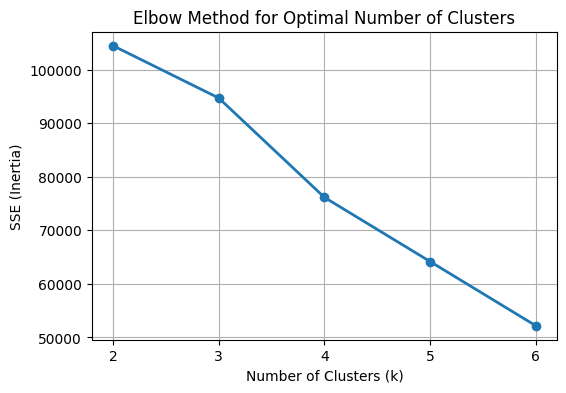

In [ ]:
# Clustering Visualization - Elbow Method

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Store SSE values
k_values = range(2,7)
sse_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    sse_values.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(k_values, sse_values, marker='o', linewidth=2)
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.xticks(k_values)
plt.grid(True)

plt.show()

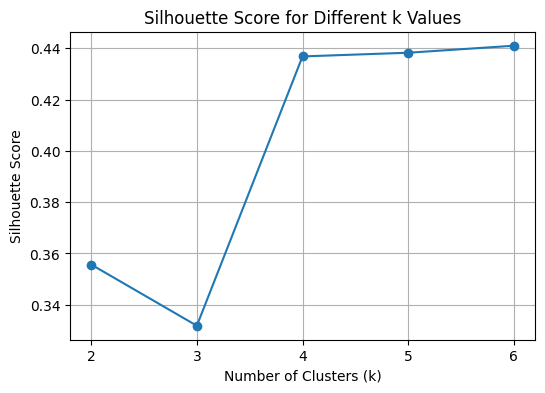

In [ ]:
# Silhouette Score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 7)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score for Different k Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

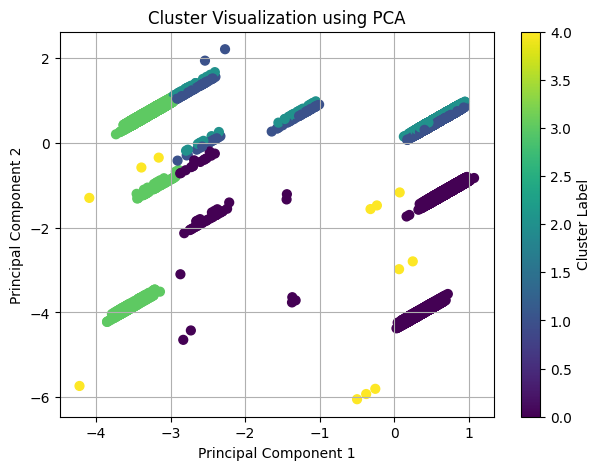

In [ ]:
# PCA
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Use optimal k from evaluation
k_optimal = 5

# Train KMeans
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster)

# Apply PCA to reduce dimensions to 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap='viridis',
    s=40
)

plt.title("Cluster Visualization using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster Label")

plt.grid(True)
plt.show()

Classification

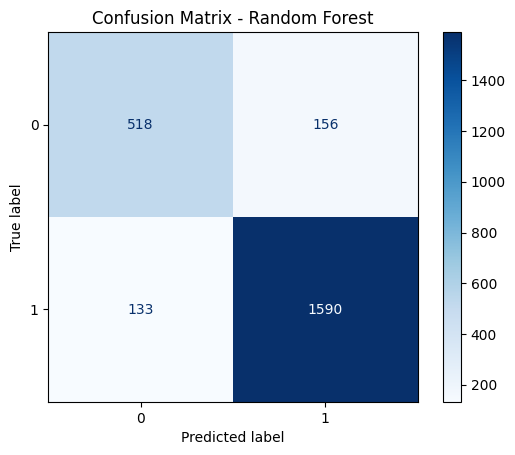

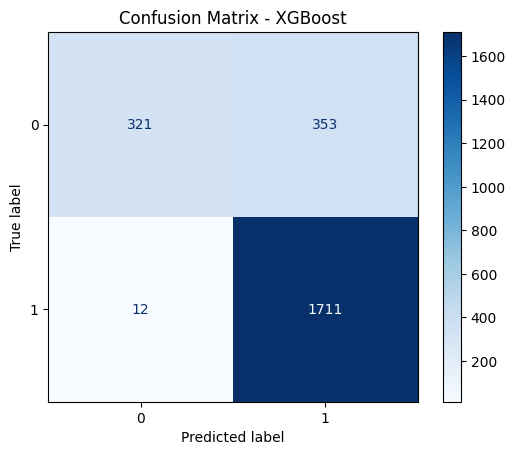

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

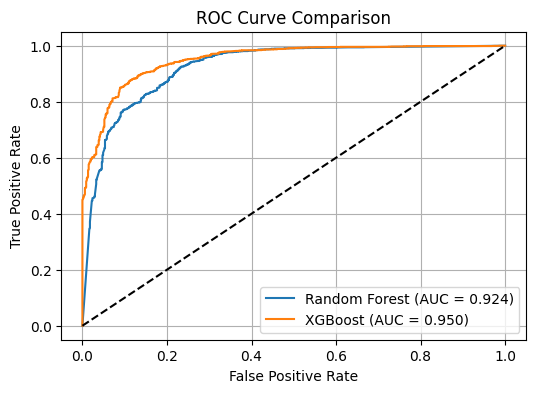

In [ ]:
# ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

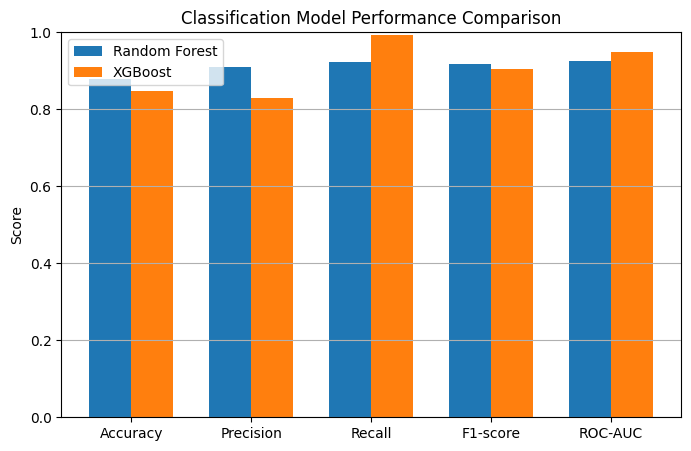

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Calculate metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']

rf_scores = [
    accuracy_score(y_test, y_pred_rf),
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf),
    roc_auc_score(y_test, y_pred_proba_rf)
]

xgb_scores = [
    accuracy_score(y_test, y_pred_xgb),
    precision_score(y_test, y_pred_xgb),
    recall_score(y_test, y_pred_xgb),
    f1_score(y_test, y_pred_xgb),
    roc_auc_score(y_test, y_pred_proba_xgb)
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, rf_scores, width, label='Random Forest')
plt.bar(x + width/2, xgb_scores, width, label='XGBoost')

plt.xticks(x, metrics)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Classification Model Performance Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()

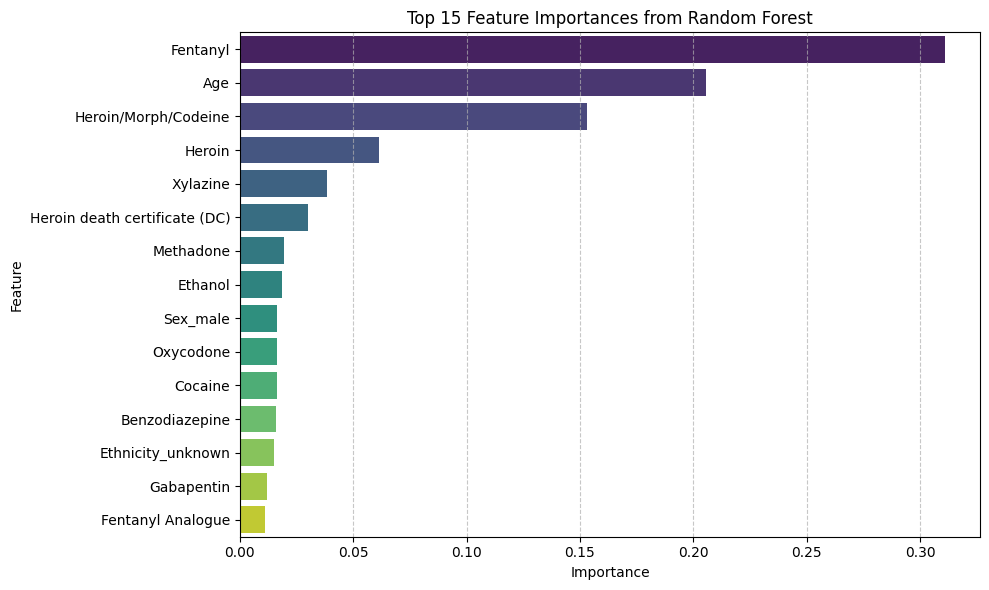

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
feature_importances = rf.feature_importances_

# Create a DataFrame for better visualization
features_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=features_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Anomaly Detection Visualization

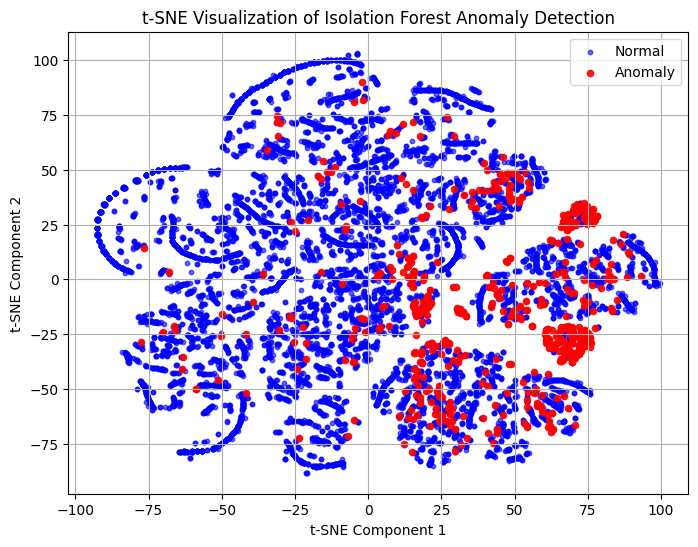

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# remove label columns
features = df_anomaly.drop(columns=['IsolationForest_Anomaly','LOF_Anomaly'], errors='ignore')

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(features)

plt.figure(figsize=(8,6))

normal = df_anomaly['IsolationForest_Anomaly'] == 1
anomaly = df_anomaly['IsolationForest_Anomaly'] == -1

plt.scatter(X_tsne[normal,0], X_tsne[normal,1],
            c='blue', s=10, alpha=0.6, label='Normal')

plt.scatter(X_tsne[anomaly,0], X_tsne[anomaly,1],
            c='red', s=20, alpha=0.9, label='Anomaly')

plt.title("t-SNE Visualization of Isolation Forest Anomaly Detection")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True)

plt.show()

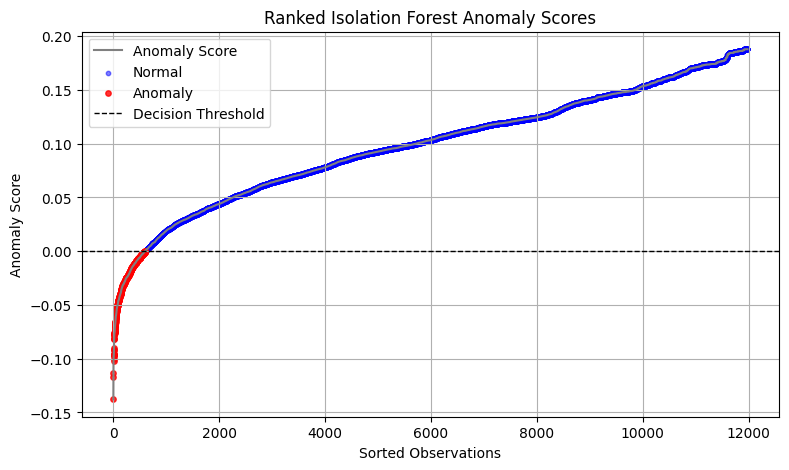

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# remove label columns if they already exist
features = df_anomaly.drop(columns=['IsolationForest_Anomaly', 'LOF_Anomaly'], errors='ignore')

# compute anomaly scores
# lower score = more abnormal in Isolation Forest
iso_scores = iso.decision_function(features)

# create dataframe for plotting
score_df = pd.DataFrame({
    'AnomalyScore': iso_scores,
    'Label': df_anomaly['IsolationForest_Anomaly']
})

# sort by score
score_df = score_df.sort_values(by='AnomalyScore').reset_index(drop=True)

# plot
plt.figure(figsize=(9,5))

plt.plot(score_df.index, score_df['AnomalyScore'], color='gray', linewidth=1.5, label='Anomaly Score')

# highlight anomalies
anomaly_idx = score_df[score_df['Label'] == -1].index
normal_idx = score_df[score_df['Label'] == 1].index

plt.scatter(normal_idx, score_df.loc[normal_idx, 'AnomalyScore'],
            color='blue', s=10, alpha=0.5, label='Normal')
plt.scatter(anomaly_idx, score_df.loc[anomaly_idx, 'AnomalyScore'],
            color='red', s=15, alpha=0.8, label='Anomaly')

# decision threshold
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='Decision Threshold')

plt.title("Ranked Isolation Forest Anomaly Scores")
plt.xlabel("Sorted Observations")
plt.ylabel("Anomaly Score")
plt.legend()
plt.grid(True)
plt.show()